# Museum Visitor Data Simulation
## Melbourne Museum of Migration

This notebook generates realistic synthetic visitor data for a museum in Melbourne, Australia.

**Key Characteristics:**
- Location: Melbourne, Australia
- Typical visitors: 200-400 per day
- Peak visitors: 1000+ during favorable conditions
- Time period: 2023-01-01 to 2025-12-31 (3 years)
- Prediction horizons: 1, 7, and 14 days ahead

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Display settings
pd.set_option('display.max_columns', None)
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    plt.style.use('seaborn-darkgrid')
sns.set_palette('husl')

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Generate Date Range

In [2]:
# Generate date range: 3 years of data
start_date = '2023-01-01'
end_date = '2025-12-31'
dates = pd.date_range(start=start_date, end=end_date, freq='D')

# Create base dataframe
df = pd.DataFrame({'date': dates})
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.dayofweek  # 0=Monday, 6=Sunday
df['day_name'] = df['date'].dt.day_name()
df['week_of_year'] = df['date'].dt.isocalendar().week
df['quarter'] = df['date'].dt.quarter

print(f"Generated {len(df)} days of data from {start_date} to {end_date}")
df.head()

Generated 1096 days of data from 2023-01-01 to 2025-12-31


,date,year,month,day,day_of_week,day_name,week_of_year,quarter
0,2023-01-01,2023,1,1,6,Sunday,52,1
1,2023-01-02,2023,1,2,0,Monday,1,1
2,2023-01-03,2023,1,3,1,Tuesday,1,1
3,2023-01-04,2023,1,4,2,Wednesday,1,1
4,2023-01-05,2023,1,5,3,Thursday,1,1


## 2. Australian Public Holidays & School Terms

In [3]:
# Australian/Victorian Public Holidays
public_holidays = [
    # 2023
    '2023-01-01', '2023-01-02', '2023-01-26', '2023-03-13', '2023-04-07', '2023-04-08',
    '2023-04-09', '2023-04-10', '2023-04-25', '2023-06-12', '2023-11-07', '2023-12-25', '2023-12-26',
    # 2024
    '2024-01-01', '2024-01-26', '2024-03-11', '2024-03-29', '2024-03-30', '2024-03-31',
    '2024-04-01', '2024-04-25', '2024-06-10', '2024-11-05', '2024-12-25', '2024-12-26',
    # 2025
    '2025-01-01', '2025-01-27', '2025-03-10', '2025-04-18', '2025-04-19', '2025-04-20',
    '2025-04-21', '2025-04-25', '2025-06-09', '2025-11-04', '2025-12-25', '2025-12-26'
]

df['is_public_holiday'] = df['date'].astype(str).isin(public_holidays).astype(int)

# Victorian School Holidays (approximate term breaks)
school_holidays = []
for year in [2023, 2024, 2025]:
    # Term 1 break (Easter)
    school_holidays.extend(pd.date_range(f'{year}-04-01', f'{year}-04-18'))
    # Term 2 break (Winter)
    school_holidays.extend(pd.date_range(f'{year}-06-24', f'{year}-07-10'))
    # Term 3 break (Spring)
    school_holidays.extend(pd.date_range(f'{year}-09-16', f'{year}-10-02'))
    # Term 4 break (Summer)
    school_holidays.extend(pd.date_range(f'{year}-12-18', f'{year}-12-31'))

df['is_school_holiday'] = df['date'].isin(school_holidays).astype(int)

print(f"Public holidays: {df['is_public_holiday'].sum()}")
print(f"School holiday days: {df['is_school_holiday'].sum()}")

Public holidays: 37
School holiday days: 198


## 3. Weather Simulation (Melbourne Climate)

In [4]:
# Melbourne weather patterns (temperate oceanic climate)
# Summer (Dec-Feb): 15-25°C, Winter (Jun-Aug): 6-14°C

def generate_temperature(month):
    """Generate realistic temperature for Melbourne based on month"""
    temp_map = {
        1: (15, 26, 5),   # Jan: Summer
        2: (15, 26, 5),   # Feb: Summer
        3: (13, 24, 4),   # Mar: Autumn
        4: (11, 20, 4),   # Apr: Autumn
        5: (8, 16, 3),    # May: Autumn
        6: (6, 14, 3),    # Jun: Winter
        7: (6, 13, 3),    # Jul: Winter
        8: (7, 15, 3),    # Aug: Winter
        9: (8, 17, 3),    # Sep: Spring
        10: (10, 20, 4),  # Oct: Spring
        11: (12, 22, 4),  # Nov: Spring
        12: (14, 25, 5)   # Dec: Summer
    }
    min_temp, max_temp, std = temp_map[month]
    avg_temp = (min_temp + max_temp) / 2
    return np.random.normal(avg_temp, std)

df['temperature'] = df['month'].apply(generate_temperature)
df['temperature'] = df['temperature'].round(1)

# Precipitation (Melbourne is known for variable weather)
df['precipitation'] = np.random.exponential(2, len(df))  # mm of rain
df['precipitation'] = df['precipitation'].round(1)

# Weather type based on precipitation
def get_weather_type(precip):
    if precip < 0.5:
        return np.random.choice(['Sunny', 'Partly Cloudy'], p=[0.7, 0.3])
    elif precip < 5:
        return 'Cloudy'
    else:
        return 'Rainy'

df['weather_type'] = df['precipitation'].apply(get_weather_type)

print("Weather features created:")
print(df[['date', 'temperature', 'precipitation', 'weather_type']].head(10))

Weather features created:
        date  temperature  precipitation weather_type
0 2023-01-01         23.0            0.8       Cloudy
1 2023-01-02         19.8            1.4       Cloudy
2 2023-01-03         23.7            0.1        Sunny
3 2023-01-04         28.1            0.3        Sunny
4 2023-01-05         19.3            8.6        Rainy
5 2023-01-06         19.3            6.7        Rainy
6 2023-01-07         28.4            0.0        Sunny
7 2023-01-08         24.3            6.1        Rainy
8 2023-01-09         18.2            2.0       Cloudy
9 2023-01-10         23.2            4.0       Cloudy


## 4. Special Events & Exhibitions

In [5]:
# Special exhibitions (3-4 per year, lasting 2-3 months each)
df['special_exhibition'] = 0

exhibitions = [
    ('2023-02-01', '2023-04-30'),
    ('2023-06-01', '2023-08-15'),
    ('2023-10-01', '2023-12-20'),
    ('2024-01-15', '2024-03-31'),
    ('2024-05-01', '2024-07-31'),
    ('2024-09-01', '2024-11-15'),
    ('2025-02-01', '2025-04-15'),
    ('2025-06-01', '2025-08-31'),
    ('2025-10-01', '2025-12-20')
]

for start, end in exhibitions:
    mask = (df['date'] >= start) & (df['date'] <= end)
    df.loc[mask, 'special_exhibition'] = 1

# Local events (Melbourne International Arts Festival, Grand Prix, etc.)
df['local_event'] = 0
major_events = [
    ('2023-03-20', '2023-03-26'),  # F1 Grand Prix
    ('2023-10-05', '2023-10-22'),  # Arts Festival
    ('2024-03-18', '2024-03-24'),  # F1 Grand Prix
    ('2024-10-03', '2024-10-20'),  # Arts Festival
    ('2025-03-17', '2025-03-23'),  # F1 Grand Prix
    ('2025-10-02', '2025-10-19')   # Arts Festival
]

for start, end in major_events:
    mask = (df['date'] >= start) & (df['date'] <= end)
    df.loc[mask, 'local_event'] = 1

print(f"Days with special exhibitions: {df['special_exhibition'].sum()}")
print(f"Days with local events: {df['local_event'].sum()}")

Days with special exhibitions: 738
Days with local events: 75


## 5. Marketing Campaigns & Promotions

In [6]:
# Marketing campaigns (random periods throughout the year)
df['marketing_campaign'] = 0
campaign_probability = 0.15  # 15% of days have active campaigns
df.loc[np.random.rand(len(df)) < campaign_probability, 'marketing_campaign'] = 1

# Ticket promotions (occasional discounts)
df['ticket_promotion'] = 0
promo_probability = 0.10  # 10% of days have promotions
df.loc[np.random.rand(len(df)) < promo_probability, 'ticket_promotion'] = 1

# Standard ticket price with occasional variations
base_price = 25  # AUD
df['ticket_price'] = base_price
df.loc[df['ticket_promotion'] == 1, 'ticket_price'] = base_price * 0.8  # 20% discount

print(f"Days with marketing campaigns: {df['marketing_campaign'].sum()}")
print(f"Days with ticket promotions: {df['ticket_promotion'].sum()}")

Days with marketing campaigns: 150
Days with ticket promotions: 115


## 6. Generate Visitor Numbers

Now we combine all factors to generate realistic visitor counts.

In [7]:
# Base visitor count (starting point)
base_visitors = 250

# Initialize visitor count
df['visitors'] = base_visitors

# 1. Day of week effect (weekends busier)
day_multiplier = {
    0: 0.90,  # Monday
    1: 0.85,  # Tuesday
    2: 0.88,  # Wednesday
    3: 0.92,  # Thursday
    4: 1.00,  # Friday
    5: 1.30,  # Saturday
    6: 1.25   # Sunday
}
df['visitors'] *= df['day_of_week'].map(day_multiplier)

# 2. Seasonal effect (Southern Hemisphere: Summer = Dec-Feb)
season_multiplier = {
    1: 1.40,   # January (Summer peak)
    2: 1.35,   # February (Summer)
    3: 1.15,   # March (Autumn)
    4: 1.05,   # April
    5: 0.90,   # May
    6: 0.80,   # June (Winter low)
    7: 0.75,   # July (Winter lowest)
    8: 0.85,   # August
    9: 1.00,   # September (Spring)
    10: 1.10,  # October
    11: 1.20,  # November
    12: 1.45   # December (Summer peak + holidays)
}
df['visitors'] *= df['month'].map(season_multiplier)

# 3. Public holiday boost
df.loc[df['is_public_holiday'] == 1, 'visitors'] *= 1.50

# 4. School holiday boost
df.loc[df['is_school_holiday'] == 1, 'visitors'] *= 1.30

# 5. Weather impact
# Good weather (sunny, warm) = more visitors
df['weather_factor'] = 1.0
df.loc[df['weather_type'] == 'Sunny', 'weather_factor'] = 1.20
df.loc[df['weather_type'] == 'Partly Cloudy', 'weather_factor'] = 1.05
df.loc[df['weather_type'] == 'Cloudy', 'weather_factor'] = 0.95
df.loc[df['weather_type'] == 'Rainy', 'weather_factor'] = 0.70

# Temperature effect (optimal around 20-24°C)
df['temp_factor'] = 1.0
df.loc[(df['temperature'] >= 20) & (df['temperature'] <= 24), 'temp_factor'] = 1.15
df.loc[df['temperature'] < 10, 'temp_factor'] = 0.85
df.loc[df['temperature'] > 32, 'temp_factor'] = 0.90  # Too hot

df['visitors'] *= df['weather_factor'] * df['temp_factor']

# 6. Special exhibitions boost
df.loc[df['special_exhibition'] == 1, 'visitors'] *= 1.25

# 7. Local events boost
df.loc[df['local_event'] == 1, 'visitors'] *= 1.40

# 8. Marketing campaign effect
df.loc[df['marketing_campaign'] == 1, 'visitors'] *= 1.15

# 9. Ticket promotion effect
df.loc[df['ticket_promotion'] == 1, 'visitors'] *= 1.20

# 10. Add realistic noise (±10-15%)
noise = np.random.normal(1.0, 0.12, len(df))
df['visitors'] *= noise

# 11. Add occasional outliers (special events, media coverage)
outlier_indices = np.random.choice(df.index, size=int(len(df) * 0.02), replace=False)
df.loc[outlier_indices, 'visitors'] *= np.random.uniform(1.5, 2.5, len(outlier_indices))

# 12. Add long-term growth trend (museum gaining popularity)
days_since_start = (df['date'] - df['date'].min()).dt.days
growth_factor = 1 + (days_since_start * 0.0001)  # Slow growth over time
df['visitors'] *= growth_factor

# Round to integer and clip to reasonable range
df['visitors'] = df['visitors'].round(0).astype(int)
df['visitors'] = df['visitors'].clip(lower=100, upper=1200)  # Reasonable bounds

print("\nVisitor Statistics:")
print(f"Mean: {df['visitors'].mean():.0f}")
print(f"Median: {df['visitors'].median():.0f}")
print(f"Min: {df['visitors'].min()}")
print(f"Max: {df['visitors'].max()}")
print(f"Std: {df['visitors'].std():.0f}")


Visitor Statistics:
Mean: 382
Median: 354
Min: 122
Max: 1100
Std: 162


## 7. Create Lagged Features (Historical Patterns)

In [8]:
# Lagged features for time series patterns
df['visitors_last_week'] = df['visitors'].shift(7)
df['visitors_last_2weeks'] = df['visitors'].shift(14)
df['visitors_last_month'] = df['visitors'].shift(30)
df['visitors_7day_avg'] = df['visitors'].rolling(window=7, min_periods=1).mean()
df['visitors_14day_avg'] = df['visitors'].rolling(window=14, min_periods=1).mean()
df['visitors_30day_avg'] = df['visitors'].rolling(window=30, min_periods=1).mean()

# Same day last year (year-over-year comparison)
df['visitors_same_day_last_year'] = df['visitors'].shift(365)

# Fill initial NaN values with mean
for col in df.columns:
    if df[col].isna().any():
        df[col].fillna(df[col].mean(), inplace=True)

print("Lagged features created successfully!")
print(df[['date', 'visitors', 'visitors_last_week', 'visitors_7day_avg']].head(20))

Lagged features created successfully!
         date  visitors  visitors_last_week  visitors_7day_avg
0  2023-01-01       743          380.191001         743.000000
1  2023-01-02       458          380.191001         600.500000
2  2023-01-03       320          380.191001         507.000000
3  2023-01-04       380          380.191001         475.250000
4  2023-01-05       224          380.191001         425.000000
5  2023-01-06       261          380.191001         397.666667
6  2023-01-07       402          380.191001         398.285714
7  2023-01-08       346          743.000000         341.571429
8  2023-01-09       305          458.000000         319.714286
9  2023-01-10       430          320.000000         335.428571
10 2023-01-11       317          380.000000         326.428571
11 2023-01-12       377          224.000000         348.285714
12 2023-01-13       346          261.000000         360.428571
13 2023-01-14       334          402.000000         350.714286
14 2023-01-15    

## 8. Data Exploration & Visualization

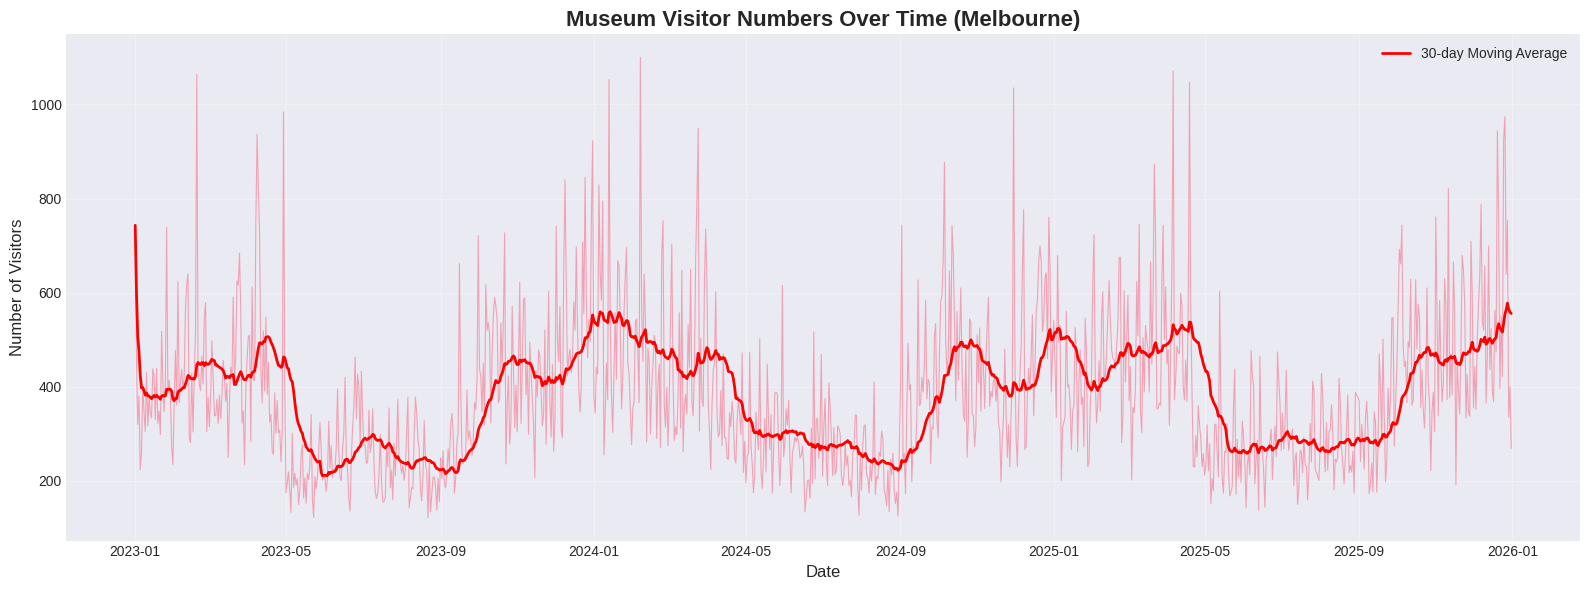

In [9]:
# Time series plot
plt.figure(figsize=(16, 6))
plt.plot(df['date'], df['visitors'], alpha=0.6, linewidth=0.8)
plt.plot(df['date'], df['visitors_30day_avg'], color='red', linewidth=2, label='30-day Moving Average')
plt.title('Museum Visitor Numbers Over Time (Melbourne)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Visitors', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

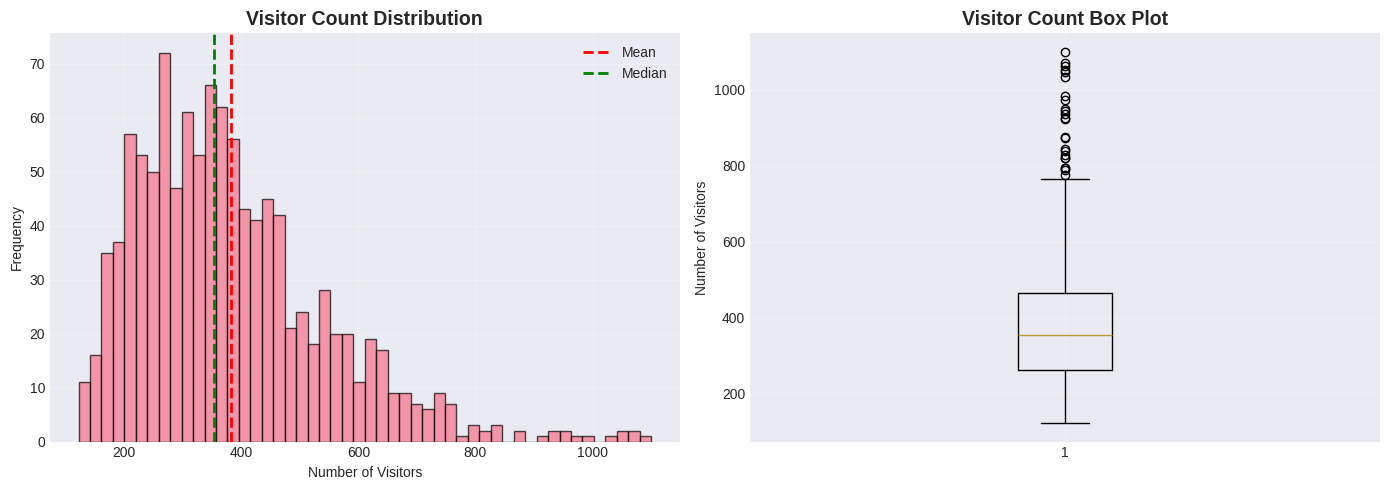

In [10]:
# Visitor distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['visitors'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(df['visitors'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0].axvline(df['visitors'].median(), color='green', linestyle='--', linewidth=2, label='Median')
axes[0].set_title('Visitor Count Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Visitors')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(df['visitors'], vert=True)
axes[1].set_title('Visitor Count Box Plot', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Visitors')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

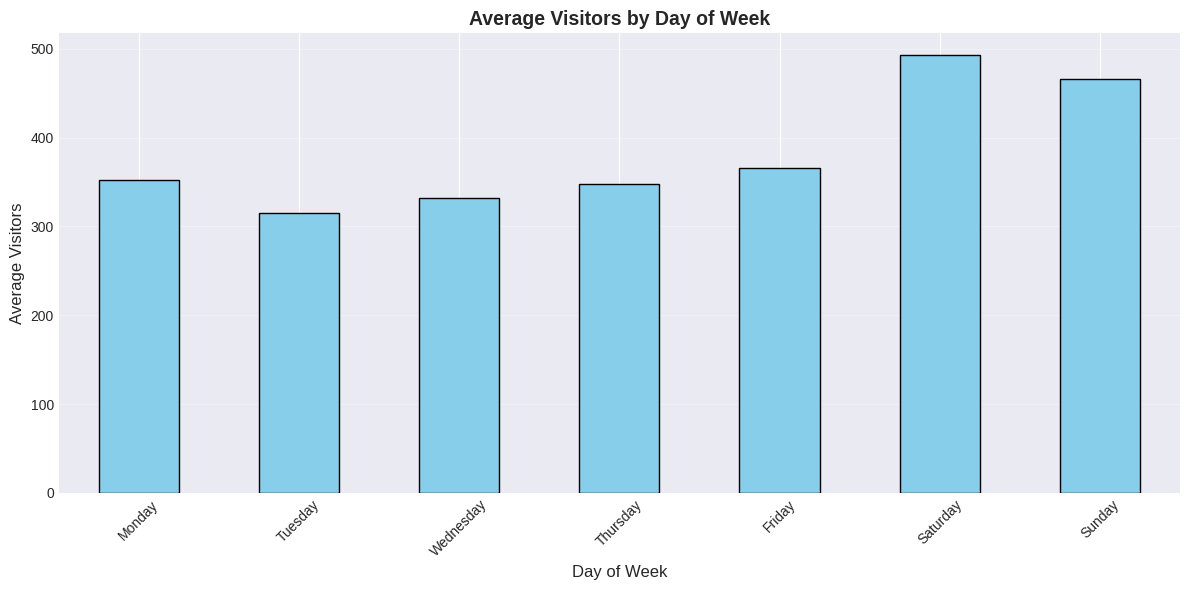

In [11]:
# Day of week pattern
plt.figure(figsize=(12, 6))
day_avg = df.groupby('day_name')['visitors'].mean().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)
day_avg.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Average Visitors by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Average Visitors', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

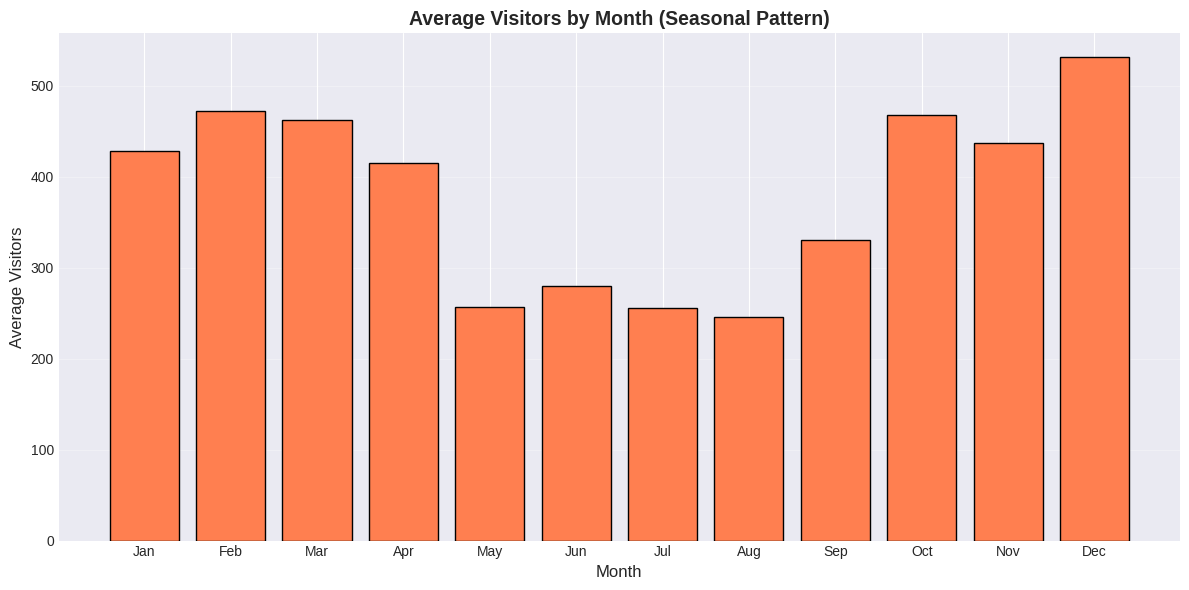

In [12]:
# Monthly pattern (showing seasonal effect)
plt.figure(figsize=(12, 6))
month_avg = df.groupby('month')['visitors'].mean()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.bar(range(1, 13), month_avg, color='coral', edgecolor='black')
plt.xticks(range(1, 13), month_names)
plt.title('Average Visitors by Month (Seasonal Pattern)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Visitors', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

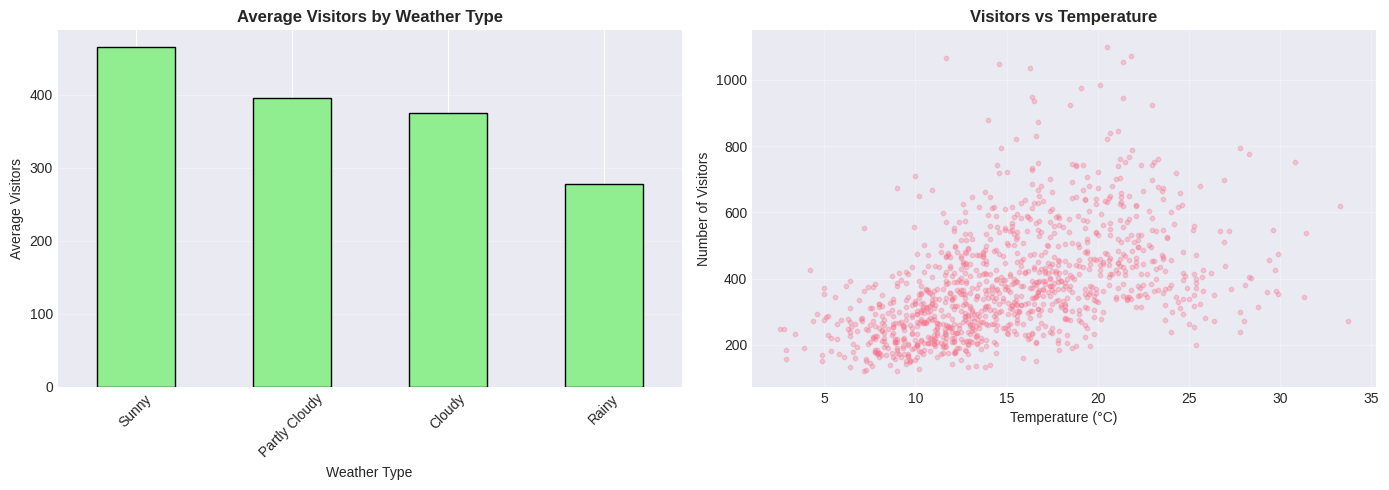

In [13]:
# Weather impact
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Weather type
weather_avg = df.groupby('weather_type')['visitors'].mean().sort_values(ascending=False)
weather_avg.plot(kind='bar', ax=axes[0], color='lightgreen', edgecolor='black')
axes[0].set_title('Average Visitors by Weather Type', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Weather Type')
axes[0].set_ylabel('Average Visitors')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# Temperature correlation
axes[1].scatter(df['temperature'], df['visitors'], alpha=0.3, s=10)
axes[1].set_title('Visitors vs Temperature', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Temperature (°C)')
axes[1].set_ylabel('Number of Visitors')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Save Dataset

In [ ]:
# Select final columns
final_columns = [
    'date', 'year', 'month', 'day', 'day_of_week', 'day_name', 'week_of_year', 'quarter',
    'is_public_holiday', 'is_school_holiday',
    'temperature', 'precipitation', 'weather_type',
    'special_exhibition', 'local_event',
    'marketing_campaign', 'ticket_promotion', 'ticket_price',
    'visitors_last_week', 'visitors_last_2weeks', 'visitors_last_month',
    'visitors_7day_avg', 'visitors_14day_avg', 'visitors_30day_avg',
    'visitors_same_day_last_year',
    'visitors'  # Target variable
]

df_final = df[final_columns].copy()

# Save to CSV
output_path = '../data/raw/museum_visitors_melbourne.csv'
df_final.to_csv(output_path, index=False)

print(f"Dataset saved to: {output_path}")
print(f"Shape: {df_final.shape}")
print(f"\nFirst few rows:")
print(df_final.head())
print(f"\nData types:")
print(df_final.dtypes)

In [15]:
# Summary statistics
print("\n=== DATASET SUMMARY ===")
print(f"Total days: {len(df_final)}")
print(f"Date range: {df_final['date'].min()} to {df_final['date'].max()}")
print(f"\nVisitor Statistics:")
print(f"  Mean: {df_final['visitors'].mean():.0f} visitors/day")
print(f"  Median: {df_final['visitors'].median():.0f} visitors/day")
print(f"  Min: {df_final['visitors'].min()} visitors/day")
print(f"  Max: {df_final['visitors'].max()} visitors/day")
print(f"  Std Dev: {df_final['visitors'].std():.0f}")
print(f"\nTotal visitors over {len(df_final)} days: {df_final['visitors'].sum():,}")
print(f"\nMissing values:")
print(df_final.isnull().sum())


=== DATASET SUMMARY ===


NameError: name 'df_final' is not defined

## Next Steps

1. **Exploratory Data Analysis** (`02_eda.ipynb`) - Deep dive into patterns and correlations
2. **Feature Engineering** (`03_feature_engineering.ipynb`) - Create additional features
3. **Modeling** (`04_modeling.ipynb`) - Train predictive models
4. **Evaluation** (`05_evaluation.ipynb`) - Assess model performance

---

**Data Ready for Modeling!** ✓